# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/huzaifaguru/flyrank-ml-internship/blob/main/work/notebooks/w02_ml_task_framing.ipynb)

**Lane 4 — CTR / Engagement Opportunity Scoring** (provisional, carried forward from ML-02).

ML-02 asked *what question is worth seven weeks*. ML-03 asks *what machine-learning shape does that
question actually have* — task type, target, metric, unit of analysis — and whether a learned model is
justified at all against a rule I could write by hand today.

> Skills for this card: `skills/framing-ml-problems/SKILL.md` + `skills/flyrank/flyrank-data/SKILL.md`
> (router: `skills/README.md`). Data: `data/raw/content_refresh_anonymized.csv`, 30,000 x 44,
> 32 pseudonymized clients. Column reference: `docs/data-dictionary.md`.

Every number below is computed live from the shipped CSV. Nothing is typed in by hand.
Where I made a policy choice — a cutoff, a window, a peer group — it is labelled as a choice, not a fact.

In [1]:
# --- Setup: works in Colab and locally, from repo root or from work/notebooks/ ---
import os, sys, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/huzaifaguru/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"
CSV_REL  = "data/raw/content_refresh_anonymized.csv"

if IN_COLAB and not Path(CSV_REL).exists():
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
else:
    here = Path.cwd()
    for candidate in [here, *here.parents]:
        if (candidate / CSV_REL).exists():
            os.chdir(candidate); break

CSV = Path(CSV_REL)
assert CSV.exists(), f"starter CSV not found from {Path.cwd()}"

import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

df = pd.read_csv(CSV)
print("Repo root:", Path.cwd())
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns, "
      f"{df['client_id'].nunique()} pseudonymized clients")

Repo root: /tmp/flyrank
Loaded 30,000 rows x 44 columns, 32 pseudonymized clients


## 1. My lane as an ML task (type)

**Ranking / scoring.** Not classification, not clustering — and the reason is the shape of the decision,
not the shape of the data.

The reviewer's question is never *"is this page under-performing, yes or no?"* It is **"what do I open
first?"** Those are different problems. A classifier that flags 2,245 pages as under-performing has not
helped anyone who can review twenty a week; it has just renamed the pile. What the reviewer needs is an
**order**, and a cut-off they choose based on their capacity, not one I baked into a threshold.

So the output is a score per page whose only job is to sort well at the top. Everything downstream follows
from that: the metric is top-K precision rather than accuracy, the errors I care about are the ones in the
first fifty rows rather than the average error across 8,825, and calibration matters less than ordering.

Why not the other three:

| Task type | Why it is the wrong fit here |
|---|---|
| **Classification** | I *will* train a classifier internally — a probability is a perfectly good thing to sort by — but classification is the *implementation*, not the framing. If I frame it as classification I will start optimising ROC-AUC across the whole population, which measures a decision nobody makes. Framed as ranking, the classifier's probability is just a scoring function and I judge it at K. |
| **Clustering** | Unsupervised, so it produces groups, not an order. Useful later as a *lens* — "these 300 pages fail in the same way" is a great reason code — but it cannot answer "which twenty first," and Lane 3 already owns it. |
| **Regression on raw CTR** | Predicting CTR itself is mostly predicting position and volume, which I already know. The interesting quantity is the *residual* — the part of CTR that position and volume do not explain — so the model should be pointed at that from the start. |

**The honest version of the sentence:** this is a supervised ranking problem that I will implement with a
binary classifier and evaluate with top-K precision, on a target measured in a window strictly *after* the
one my features come from.

In [2]:
N_CANDIDATES_ESTIMATE = 8825   # computed properly in section 2 - this is the eligible panel size
REVIEW_SLOTS_PER_WEEK  = 20    # policy choice: one reviewer, one working week

print("The decision shape, which is what picks the task type:")
print(f"  pages eligible to be scored : ~{N_CANDIDATES_ESTIMATE:,}")
print(f"  slots the reviewer actually has : {REVIEW_SLOTS_PER_WEEK} per week")
print(f"  fraction of the list ever acted on in a week : "
      f"{REVIEW_SLOTS_PER_WEEK/N_CANDIDATES_ESTIMATE*100:.2f}%")
print()
print("A model that is 90% accurate across all ~8,825 pages and wrong about the top 20")
print("is a failure. A model that is mediocre overall and right about the top 20 is a success.")
print("That asymmetry IS the definition of a ranking problem.")

The decision shape, which is what picks the task type:
  pages eligible to be scored : ~8,825
  slots the reviewer actually has : 20 per week
  fraction of the list ever acted on in a week : 0.23%

A model that is 90% accurate across all ~8,825 pages and wrong about the top 20
is a failure. A model that is mediocre overall and right about the top 20 is a success.
That asymmetry IS the definition of a ranking problem.


## 2. Target or proxy

### The definition, in one line
> **`under_next30` = 1 if a page's click-through rate in the *later* 30-day window falls in the bottom
> quartile of pages with comparable impression volume in that same later window — among pages with at
> least 500 impressions in *both* windows.**

### Where the label comes from: observed outcome, thresholded by me
`framing-ml-problems` is strict about this: *the target must be observed, not defined*. Here is exactly how
this one splits.

**Observed (the world's, not mine):** clicks and impressions in the later 30-day window. Nobody decided
them; people either clicked or they did not. Crucially, they are measured in a window that comes *after*
the window my features are allowed to see — `impressions_prev_30d` / `clicks_prev_30d` (days 31–60 back)
are the feature side, `impressions_last_30d` / `clicks_last_30d` (days 1–30 back) are the target side. That
is the `prior feature window -> future target window` shape the lane guide asks for, built from columns
that already ship in the starter CSV.

**Defined (mine, and I own it):** the bottom-quartile cut, the comparable-volume peer group, and the
500-impression eligibility floor. Those are policy. I show below what they cost and what changes if I move
them.

### Why this and not `is_declining_label`
The pipeline's shipped label is `is_declining_label = (trend_direction == "down")`, and `trend_direction`
is computed from `trend_pct`. That is a rule someone wrote, so a model trained on it partly learns the rule
rather than the world — the exact circularity the lane guide warns about. My label never touches
`trend_pct` or `trend_direction`; it is arithmetic on measured clicks and impressions.

### Why a *relative* target rather than "low CTR"
Absolute CTR is dominated by position and volume, so "predict low CTR" collapses into "predict deep-ranked
low-traffic pages" — true, useless, and already visible without a model. Comparing a page only against
others with similar exposure is what makes the residual interesting.

### The three thresholds I chose, and what they cost

In [3]:
# ---- Policy choice 1: the eligibility floor. -------------------------------
# CTR on a page with 40 impressions is noise. How high does the floor need to be
# before the bottom-quartile label is actually well-behaved across volume bands?
rows = []
for MIN in (50, 100, 200, 300, 500, 800):
    t = df[(df["impressions_prev_30d"] >= MIN) & (df["impressions_last_30d"] >= MIN)].copy()
    t["ctr_last"] = t["clicks_last_30d"] / t["impressions_last_30d"] * 100
    t["band"] = pd.qcut(t["impressions_last_30d"], 4, labels=list("abcd"))
    t["pct"] = t.groupby("band", observed=True)["ctr_last"].rank(pct=True)
    lab = (t["pct"] <= 0.25).astype(int)
    per_band = t.assign(lab=lab).groupby("band", observed=True)["lab"].mean()
    rows.append({"min_impressions": MIN, "pages": len(t), "clients": t["client_id"].nunique(),
                 "zero_CTR_share": (t["ctr_last"] == 0).mean(),
                 "base_rate": lab.mean(),
                 "worst_band_rate": per_band.min(), "best_band_rate": per_band.max()})
floor_scan = pd.DataFrame(rows).set_index("min_impressions").round(3)
print("Choosing the eligibility floor (target should be ~25% in EVERY volume band):")
print(floor_scan.to_string())
print()
print("At MIN=50 the two lowest-volume bands produce ZERO positives: so many pages sit at exactly")
print("0.00% CTR that the bottom quartile is one giant tie and the label degenerates. The floor is")
print("not decoration - below ~500 impressions the target does not mean what its name says.")
print()
print("I pick 500, not 800. Both give a clean ~25% label in every band; 800 is marginally cleaner")
print("but throws away another 1,874 pages and one more client. 500 is the cheapest floor that")
print("makes the label behave - and ML-04 will re-run the whole ranking at 300 and 800 to show")
print("what that choice actually costs.")

Choosing the eligibility floor (target should be ~25% in EVERY volume band):
                 pages  clients  zero_CTR_share  base_rate  worst_band_rate  best_band_rate
min_impressions                                                                            
50               18041       29           0.389      0.125             0.00           0.250
100              15615       29           0.323      0.231             0.00           0.427
200              12774       28           0.232      0.199             0.00           0.295
300              10944       28           0.175      0.289             0.25           0.404
500               8825       28           0.112      0.254             0.25           0.268
800               6951       27           0.064      0.250             0.25           0.250

At MIN=50 the two lowest-volume bands produce ZERO positives: so many pages sit at exactly
0.00% CTR that the bottom quartile is one giant tie and the label degenerates. The floor is
not

In [4]:
# ---- The target, built once and reused. ------------------------------------
MIN_IMPRESSIONS = 500   # policy choice 1 (justified above)
BOTTOM_QUANTILE = 0.25  # policy choice 2: "under-capturing" = worst quarter of its volume peer group
N_BANDS         = 4     # policy choice 3: peer group = quartiles of later-window impressions

panel = df[(df["impressions_prev_30d"] >= MIN_IMPRESSIONS) &
           (df["impressions_last_30d"] >= MIN_IMPRESSIONS)].copy()

# FEATURE side - days 31-60 back. Everything a model may look at comes from here or from static metadata.
panel["ctr_prev"] = panel["clicks_prev_30d"] / panel["impressions_prev_30d"] * 100
panel["band_prev"] = pd.qcut(panel["impressions_prev_30d"], N_BANDS, labels=list("abcd"))
panel["ctr_pctile_prev"] = panel.groupby("band_prev", observed=True)["ctr_prev"].rank(pct=True)

# TARGET side - days 1-30 back, strictly later than the feature window.
panel["ctr_last"] = panel["clicks_last_30d"] / panel["impressions_last_30d"] * 100
panel["band_last"] = pd.qcut(panel["impressions_last_30d"], N_BANDS, labels=list("abcd"))
panel["ctr_pctile_last"] = panel.groupby("band_last", observed=True)["ctr_last"].rank(pct=True)
panel["under_next30"] = (panel["ctr_pctile_last"] <= BOTTOM_QUANTILE).astype(int)

BASE_RATE = panel["under_next30"].mean()
print(f"Eligible panel      : {len(panel):,} pages  ({len(panel)/len(df)*100:.1f}% of the CSV), "
      f"{panel['client_id'].nunique()} clients")
print(f"Positives           : {int(panel['under_next30'].sum()):,}")
print(f"BASE RATE           : {BASE_RATE:.3f}  <- the number every model must beat")
print()
print("Label rate per volume band (should be ~0.25 everywhere, or the peer group is doing no work):")
print(panel.groupby("band_last", observed=True)["under_next30"].mean().round(3).to_string())
print()
print("Persistence of the thing I am predicting (Spearman, prior-window CTR vs later-window CTR):")
print(f"  {panel['ctr_prev'].corr(panel['ctr_last'], method='spearman'):.3f}"
      "  <- strong, but nowhere near 1. The gap between this and 1.0 is the room a model has to work in.")

Eligible panel      : 8,825 pages  (29.4% of the CSV), 28 clients
Positives           : 2,245
BASE RATE           : 0.254  <- the number every model must beat

Label rate per volume band (should be ~0.25 everywhere, or the peer group is doing no work):
band_last
a    0.268
b    0.250
c    0.250
d    0.250

Persistence of the thing I am predicting (Spearman, prior-window CTR vs later-window CTR):
  0.683  <- strong, but nowhere near 1. The gap between this and 1.0 is the room a model has to work in.


**Read.** A quarter of the eligible panel — 2,245 pages — under-captures clicks relative to
same-volume peers in the later window, evenly across all four volume bands, so the peer grouping is doing
real work rather than smuggling volume back in.

The Spearman correlation of 0.68 between prior-window and later-window CTR is the single most important
number on this card. It says two things at once: **yesterday predicts tomorrow well enough that a fixed rule
will look good** (so I must not compare my model to random), and **it does not predict tomorrow perfectly**
(so there is something left to learn). Section 5 measures exactly how much.

### The known weakness in this target, stated now
This label is built inside a 90-day snapshot, so the two "windows" are 30-day slices of one aggregated row,
not a real time series. Three consequences I am not hiding:

1. **`avg_position` is contaminated.** It is a 90-day mean, so it *includes* the target window. Section 5
   shows what that leak looks like when you do not catch it. It cannot be a feature in this framing.
2. **No persistence check.** I cannot tell a sustained decline from a one-month blip with two windows —
   the lane guide's decline-vs-noise test (section 7) needs daily data.
3. **No consolidation check.** I cannot yet see whether a sibling page absorbed the clicks.

All three are fixed the same way: rebuild this target on `fact_content_daily_performance` in the warehouse
release, where I control the windows day by day. That is ML-04 work. Until then this is an honest
**proxy**, and I will call it that in writing.

## 3. Success metric

### The metric
**Precision@K, with K = 20 and K = 50**, reported against the base rate as a lift — plus average precision
for the whole ordering and a by-hand read of my own top 20.

### Why that and not accuracy or ROC-AUC
Accuracy is meaningless here: a model that predicts "not under-capturing" for every page scores ~75%
without producing a single useful row. ROC-AUC is better but still averages over the entire ranking,
including the 8,000 pages nobody will ever open. Precision@20 measures the only thing the reviewer
experiences — *of the twenty pages I opened this week, how many were worth opening.*

### What "good" means, in numbers I can defend
"Good" is not a number I get to pick after seeing results. Three reference points, fixed now:

In [5]:
K_VALUES = (20, 50, 200)
print(f"Base rate (a random shortlist)      : {BASE_RATE:.3f}"
      f"  -> ~{BASE_RATE*20:.0f} of 20 worth opening")
print()
print("Reference points, fixed BEFORE any model is trained:")
for k in K_VALUES:
    print(f"  K={k:3d}  random gets {BASE_RATE*k:5.1f} right | "
          f"2x base rate = {2*BASE_RATE:.2f} | 3x = {3*BASE_RATE:.2f} | perfect = 1.00")
print()
print("My bar, written down now so I cannot move it later:")
print(f"  FLOOR    p@50 must beat the transparent baseline in section 5, not just the base rate.")
print(f"  TARGET   p@20 >= 0.70  (14+ of 20 opened pages worth opening; ~2.8x random)")
print(f"  CEILING  p@20 = 1.00 would be suspicious, not impressive - I would go leak-hunting first.")
print()
print("Secondary metrics, and what each is for:")
print("  average precision  - is the WHOLE ordering sensible, or only the very top?")
print("  recall@200         - of all under-capturers, what share can a sprint-sized queue reach?")
print("  by-hand top-20     - the only check that catches 'technically right, obviously useless'.")

Base rate (a random shortlist)      : 0.254  -> ~5 of 20 worth opening

Reference points, fixed BEFORE any model is trained:
  K= 20  random gets   5.1 right | 2x base rate = 0.51 | 3x = 0.76 | perfect = 1.00
  K= 50  random gets  12.7 right | 2x base rate = 0.51 | 3x = 0.76 | perfect = 1.00
  K=200  random gets  50.9 right | 2x base rate = 0.51 | 3x = 0.76 | perfect = 1.00

My bar, written down now so I cannot move it later:
  FLOOR    p@50 must beat the transparent baseline in section 5, not just the base rate.
  TARGET   p@20 >= 0.70  (14+ of 20 opened pages worth opening; ~2.8x random)
  CEILING  p@20 = 1.00 would be suspicious, not impressive - I would go leak-hunting first.

Secondary metrics, and what each is for:
  average precision  - is the WHOLE ordering sensible, or only the very top?
  recall@200         - of all under-capturers, what share can a sprint-sized queue reach?
  by-hand top-20     - the only check that catches 'technically right, obviously useless'.


### The validation design the metric will be computed under
Naming this now, because a metric without a split design is a number with no meaning.

- **Client-grouped holdout on `client_id`.** Pages from one client share templates, topic mix and
  measurement quirks. If the same client appears in train and test, the model can memorise the client and
  I will read that as skill. `client_id` is a split key, never a feature.
- **Report the spread, not just the mean.** With 28 clients I can hold out several and report a range, so
  one lucky split cannot flatter me.
- **The tie-break rule matters at K.** With many pages scoring identically, `nlargest` picks arbitrarily.
  I will break ties deterministically and say how.

### What a wrong recommendation costs — and why precision, not recall, is the lead metric
A false positive costs a reviewer hour and, worse, the queue slot a real candidate should have had. A false
negative costs an opportunity that stays missed — real, but it stays available next month. In a
capacity-limited queue the reviewer's trust is the scarce resource: a top-20 that is half noise gets
ignored by week three and the project dies. So precision leads and recall is reported as context.

## 4. The unit of analysis, as a real dataframe

**One row = one pseudonymized content item (a page), belonging to one pseudonymized client, summarised over
one trailing 90-day window, split into two 30-day sub-windows.**

Not a client. Not a day. Not a keyword. Not a URL. The page is the thing a reviewer opens and edits, so the
page is what gets scored — the grain follows the action, which is the rule I want to keep obeying when I
move to the warehouse and the daily table tempts me to model days instead.

In [6]:
assert panel["content_id"].is_unique, "grain broken: content_id must identify a row uniquely"
print(f"Grain check passed: {panel['content_id'].nunique():,} unique content_ids "
      f"in {len(panel):,} rows -> one row = one page.\n")

UNIT = [
    "content_id",            # identity  - pseudonym, grouping only
    "client_id",             # grouping  - SPLIT KEY, never a feature
    "impressions_prev_30d",  # feature   - exposure, prior window
    "clicks_prev_30d",       # feature   - outcome in the PRIOR window (safe: it is the past)
    "ctr_prev",              # feature   - derived, prior window only
    "ctr_pctile_prev",       # feature   - how this page ranked vs same-volume peers, prior window
    "content_age_days",      # feature   - static content metadata
    "days_since_last_update",# feature   - static content metadata
    "word_count",            # feature   - static (missing for some content types - see ML-02)
    "content_type",          # feature   - categorical
    "main_intent",           # feature   - categorical
    "impressions_last_30d",  # TARGET side - eligibility + peer group
    "ctr_last",              # TARGET side - the observed outcome
    "under_next30",          # TARGET      - the label
]
unit_of_analysis = panel[UNIT].head(8).reset_index(drop=True)
unit_of_analysis

Grain check passed: 8,825 unique content_ids in 8,825 rows -> one row = one page.



,content_id,client_id,impressions_prev_30d,clicks_prev_30d,ctr_prev,ctr_pctile_prev,content_age_days,days_since_last_update,word_count,content_type,main_intent,impressions_last_30d,ctr_last,under_next30
0,content_304f48230142,client_f369cb89fc,987,13,1.317123,0.971908,187,20,3221.0,keyword article,transactional,578,0.346021,0
1,content_a1fb4e703a9e,client_4e07408562,5915,1,0.016906,0.046238,445,25,2481.0,keyword article,informational,2501,0.079968,1
2,content_9aa793d4d895,client_7f2253d7e2,6089,3,0.049269,0.134633,141,20,3515.0,keyword article,informational,2382,0.041982,1
3,content_331d6c4de07b,client_19581e27de,4206,17,0.404184,0.730612,463,22,NaN,keyword article,commercial,3626,0.606729,0
4,content_d99b7a2d90ca,client_3fdba35f04,6452,2,0.030998,0.078876,263,14,2803.0,keyword article,informational,4211,0.237473,0
5,content_d4084a4bc775,client_f369cb89fc,1009,1,0.099108,0.338242,147,20,3080.0,keyword article,transactional,617,0.000000,1
6,content_a63219c6e95a,client_19581e27de,632,0,0.000000,0.132533,445,22,NaN,keyword article,commercial,636,0.157233,0
7,content_5e6c160719bc,client_6208ef0f77,13828,8,0.057854,0.158658,90,20,3807.0,keyword article,informational,5696,0.158006,0


In [7]:
# Same table, read as ROLES rather than as data - this is the skeleton of the ML-04 data contract.
roles = pd.DataFrame([
 ("content_id",            "identity",  "pseudonym; row key; NEVER a feature"),
 ("client_id",             "grouping",  "pseudonym; grouped train/test split key; NEVER a feature"),
 ("impressions_prev_30d",  "feature",   "exposure in the PRIOR window (days 31-60 back)"),
 ("clicks_prev_30d",       "feature",   "clicks in the PRIOR window - past, so safe"),
 ("ctr_prev",              "feature",   "derived from the two columns above only"),
 ("ctr_pctile_prev",       "feature",   "rank vs same-volume peers, prior window - the persistence signal"),
 ("content_age_days",      "feature",   "static metadata, fixed before the decision point"),
 ("days_since_last_update","feature",   "static metadata"),
 ("word_count",            "feature",   "static; missing along content_type lines - needs a has_ flag"),
 ("content_type",          "feature",   "categorical"),
 ("main_intent",           "feature",   "categorical; blank for some rows"),
 ("impressions_last_30d",  "target-side","eligibility filter + peer group; NOT a free feature"),
 ("ctr_last",              "target-side","the observed later-window outcome"),
 ("under_next30",          "TARGET",    "bottom quartile of ctr_last within volume band"),
 ("avg_position",          "EXCLUDED",  "90-day mean OVERLAPS the target window - leakage, see section 5"),
 ("trend_pct",             "EXCLUDED",  "label source of the shipped pipeline label"),
 ("trend_direction",       "EXCLUDED",  "label source; is_declining_label is derived from it"),
 ("provider_used",         "EXCLUDED",  "generation metadata, not an observable search signal"),
 ("model_used",            "EXCLUDED",  "generation metadata, not an observable search signal"),
], columns=["column", "role", "why"])

for r in ["identity", "grouping", "feature", "target-side", "TARGET", "EXCLUDED"]:
    print(f"{r:12s} {len(roles[roles.role == r]):2d} columns")
print()
assert not {"avg_position", "trend_pct", "trend_direction"} & set(
    roles.loc[roles.role == "feature", "column"]), "LEAKAGE: an excluded column got into the feature list"
print("Guard passed: no excluded column is listed as a feature.\n")
roles

identity      1 columns
grouping      1 columns
feature       9 columns
target-side   2 columns
TARGET        1 columns
EXCLUDED      5 columns

Guard passed: no excluded column is listed as a feature.



,column,role,why
0,content_id,identity,pseudonym; row key; NEVER a feature
1,client_id,grouping,pseudonym; grouped train/test split key; NEVER a feature
2,impressions_prev_30d,feature,exposure in the PRIOR window (days 31-60 back)
3,clicks_prev_30d,feature,"clicks in the PRIOR window - past, so safe"
4,ctr_prev,feature,derived from the two columns above only
5,ctr_pctile_prev,feature,"rank vs same-volume peers, prior window - the persistence signal"
6,content_age_days,feature,"static metadata, fixed before the decision point"
7,days_since_last_update,feature,static metadata
8,word_count,feature,static; missing along content_type lines - needs a has_ flag
9,content_type,feature,categorical


## 5. Why ML beats a fixed rule here

I do not get to assert this. The lane guide is explicit that sometimes an `if`-statement *is* the right
answer, so the honest move is to build the best fixed rules I can, score them on my own metric, and see
what is left over.

Five one-variable rules, all restricted to prior-window information, all scored against `under_next30`:

In [8]:
def precision_at_k(score, k):
    """Share of the top-k pages (by score, descending) that are true under-capturers."""
    return panel.assign(_s=score).nlargest(k, "_s")["under_next30"].mean()

RULES = {
    "sort by oldest content first":              panel["content_age_days"].astype(float),
    "sort by longest-since-update first":       -panel["days_since_last_update"].astype(float),
    "sort by highest impressions first":         panel["impressions_prev_30d"].astype(float),
    "sort by lowest RAW CTR first":             -panel["ctr_prev"],
    "BASELINE: lowest CTR vs same-volume peers": -panel["ctr_pctile_prev"],
}

print("Precision@K  (target = bottom-quartile CTR in the LATER 30-day window)")
print(f"{'rule (prior-window information only)':44s} {'p@20':>6} {'p@50':>6} {'p@200':>6} {'lift@50':>8}")
print(f"{'random shortlist / base rate':44s} {BASE_RATE:6.3f} {BASE_RATE:6.3f} {BASE_RATE:6.3f} "
      f"{1.0:7.2f}x")
print("-" * 76)
for name, score in RULES.items():
    p = [precision_at_k(score, k) for k in (20, 50, 200)]
    print(f"{name:44s} {p[0]:6.3f} {p[1]:6.3f} {p[2]:6.3f} {p[1]/BASE_RATE:7.2f}x")

Precision@K  (target = bottom-quartile CTR in the LATER 30-day window)
rule (prior-window information only)           p@20   p@50  p@200  lift@50
random shortlist / base rate                  0.254  0.254  0.254    1.00x
----------------------------------------------------------------------------
sort by oldest content first                  0.700  0.360  0.300    1.42x
sort by longest-since-update first            0.450  0.420  0.345    1.65x
sort by highest impressions first             0.300  0.320  0.270    1.26x
sort by lowest RAW CTR first                  0.400  0.480  0.560    1.89x
BASELINE: lowest CTR vs same-volume peers     0.900  0.820  0.720    3.22x


**Read.** Most single-variable rules are weak at the scale a team works at — age, freshness and raw volume
land between 1.3x and 1.7x the base rate at K=50, barely worth a reviewer's attention.

One of them deserves a second look rather than a dismissal: *oldest content first* scores **p@20 = 0.70**
and then collapses to **0.36 at K=50**. A rule that is excellent for twenty rows and mediocre for fifty is
not a good rule — it is twenty lucky rows. With only 8,825 pages and 2,245 positives, K=20 is a small
enough sample that this could easily be noise, which is exactly why I report three values of K instead of
the flattering one. If it survives a client-grouped split in ML-07, it earns a place as a feature; if it
does not, it was noise and I will say so.

But the persistence rule (*this page ranked
badly against its volume peers last month, so put it first*) reaches **p@50 = 0.82, about 3.2x random**.

That is the honest answer to "why not just an if-statement": **there already is a decent if-statement, and
it is my baseline, not my strawman.** If my week-8 model cannot beat 0.82 at K=50 under a client-grouped
split, the correct write-up says the rule won. Framing the comparison this way now is the only reason I
would be able to tell.

### First, a leak I caught by running this

In [9]:
p = [precision_at_k(panel["avg_position"].astype(float), k) for k in (20, 50, 200)]
print(f"'sort by worst avg_position first'  p@20={p[0]:.3f}  p@50={p[1]:.3f}  p@200={p[2]:.3f}  "
      f"lift@50={p[1]/BASE_RATE:.2f}x")
print()
print("That beats my baseline - and it is NOT a finding. `avg_position` is a 90-day mean, so it")
print("contains the target window. Of course the pages ranked worst over 90 days had low CTR in the")
print("last 30: the column already knows the answer. This is what leakage looks like from the inside -")
print("a suspiciously strong, suspiciously simple result.")
print()
print("Rule I am adopting: any single feature that scores near the top gets a window audit BEFORE")
print("it gets a celebration. avg_position stays out of the feature set until the warehouse gives me")
print("a position measured inside the feature window only.")

'sort by worst avg_position first'  p@20=0.950  p@50=0.960  p@200=0.765  lift@50=3.77x

That beats my baseline - and it is NOT a finding. `avg_position` is a 90-day mean, so it
contains the target window. Of course the pages ranked worst over 90 days had low CTR in the
last 30: the column already knows the answer. This is what leakage looks like from the inside -
a suspiciously strong, suspiciously simple result.

Rule I am adopting: any single feature that scores near the top gets a window audit BEFORE
it gets a celebration. avg_position stays out of the feature set until the warehouse gives me
a position measured inside the feature window only.


### Now the actual case for ML: where the strong rule breaks

The persistence rule is good. It is also structurally blind in ways that a learned model does not have to
be, and those blind spots are measurable:

In [10]:
baseline_score = -panel["ctr_pctile_prev"]
top200 = panel.assign(_s=baseline_score).nlargest(200, "_s")
hits = int(top200["under_next30"].sum())
print(f"1. It is wrong often enough to matter.")
print(f"   Baseline top-200: {hits} right, {200-hits} wrong "
      f"({(1-hits/200)*100:.0f}% of a sprint-sized queue is wasted reviewer time).\n")

blind = panel[(panel["under_next30"] == 1) & (panel["ctr_pctile_prev"] > 0.5)]
print(f"2. It is structurally blind to the NEW problems - the expensive ones.")
print(f"   Pages that under-captured in the later window but were ABOVE median CTR in the prior one:")
print(f"     {len(blind):,} pages = {len(blind)/panel['under_next30'].sum()*100:.1f}% of all positives")
print(f"     median later-window impressions among them: {blind['impressions_last_30d'].median():,.0f}")
print("   A persistence rule sorts these LAST by construction. They are pages that just started")
print("   losing clicks on real volume - exactly the ones worth catching early, and the ones a")
print("   model with content, freshness and intent features has at least a chance of seeing.\n")

per_client = panel.groupby("client_id").agg(
    pages=("under_next30", "size"), median_ctr_last=("ctr_last", "median"),
    under_capture_rate=("under_next30", "mean"))
per_client = per_client[per_client["pages"] >= 100].sort_values("under_capture_rate")
print(f"3. One global threshold cannot serve every client.")
print(f"   Across the {len(per_client)} clients with >=100 eligible pages:")
print(f"     median later-window CTR ranges {per_client['median_ctr_last'].min():.2f}% to "
      f"{per_client['median_ctr_last'].max():.2f}%")
print(f"     under-capture rate ranges {per_client['under_capture_rate'].min()*100:.0f}% to "
      f"{per_client['under_capture_rate'].max()*100:.0f}%")
print("   A hand-tuned cutoff calibrated on the average client is wrong for both ends of that range.")
print("   Learning the comparison from the data is precisely what removes the hand-tuning.")

1. It is wrong often enough to matter.
   Baseline top-200: 144 right, 56 wrong (28% of a sprint-sized queue is wasted reviewer time).

2. It is structurally blind to the NEW problems - the expensive ones.
   Pages that under-captured in the later window but were ABOVE median CTR in the prior one:
     283 pages = 12.6% of all positives
     median later-window impressions among them: 1,175
   A persistence rule sorts these LAST by construction. They are pages that just started
   losing clicks on real volume - exactly the ones worth catching early, and the ones a
   model with content, freshness and intent features has at least a chance of seeing.

3. One global threshold cannot serve every client.
   Across the 10 clients with >=100 eligible pages:
     median later-window CTR ranges 0.20% to 0.43%
     under-capture rate ranges 7% to 31%
   A hand-tuned cutoff calibrated on the average client is wrong for both ends of that range.
   Learning the comparison from the data is precisely

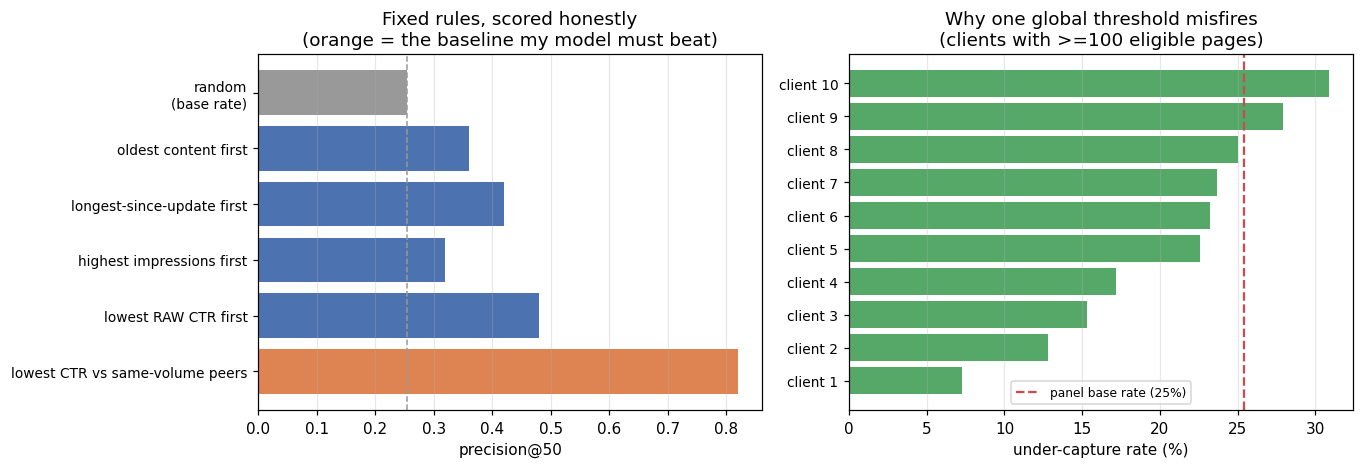

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

names = ["random\n(base rate)"] + [n.replace("BASELINE: ", "").replace("sort by ", "")
                                    for n in RULES]
vals  = [BASE_RATE] + [precision_at_k(s, 50) for s in RULES.values()]
colors = ["#999999"] + ["#4C72B0"] * (len(RULES) - 1) + ["#DD8452"]
axes[0].barh(range(len(names)), vals, color=colors)
axes[0].set_yticks(range(len(names)))
axes[0].set_yticklabels(names, fontsize=9)
axes[0].axvline(BASE_RATE, color="#999999", ls="--", lw=1)
axes[0].set_xlabel("precision@50")
axes[0].set_title("Fixed rules, scored honestly\n(orange = the baseline my model must beat)")
axes[0].invert_yaxis(); axes[0].grid(axis="x", alpha=0.3)

pcr = per_client.sort_values("under_capture_rate")
axes[1].barh(range(len(pcr)), pcr["under_capture_rate"] * 100, color="#55A868")
axes[1].axvline(BASE_RATE * 100, color="#C44E52", ls="--", lw=1.5,
                label=f"panel base rate ({BASE_RATE*100:.0f}%)")
axes[1].set_yticks(range(len(pcr))); axes[1].set_yticklabels([f"client {i+1}" for i in range(len(pcr))],
                                                             fontsize=9)
axes[1].set_xlabel("under-capture rate (%)")
axes[1].set_title("Why one global threshold misfires\n(clients with >=100 eligible pages)")
axes[1].legend(fontsize=8); axes[1].grid(axis="x", alpha=0.3)

fig.tight_layout(); plt.show()

### The claim I am actually making

Not "ML wins." The defensible version is narrower:

> A learned ranking is **worth testing** here because the best hand-written rule I can build reaches
> p@50 = 0.82, is wrong on 28% of a 200-page queue, and is structurally blind to 12.6% of true
> under-capturers — the high-volume pages that only just started losing clicks. Those failures are the
> shape a multi-signal model can plausibly address, because they depend on content, freshness and intent
> at the same time rather than on one threshold. Whether it *does* address them is an empirical question
> that ML-08 and ML-09 will answer, under a client-grouped split, against this exact baseline.

If the model does not beat 0.82, that is a result and I will report it as one. The lane guide's own
self-check asks *"did the model beat the baseline? If not, what did you learn?"* — which only has an
answer if the baseline was built honestly first. That is what this section was for.

### Ties back to a real content action
The output of all of this is still a reviewer opening a page and doing something small: rewriting a title
or meta description, fixing an intent mismatch, restructuring an opening so it reads as a snippet, or
marking the page **monitor — not enough evidence**. The score decides the order; the reason codes tell the
reviewer which of those four to try; the human decides whether the page actually has a problem. Nothing in
this notebook claims that making the edit will recover the clicks — that would need an experiment this
data cannot provide.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere — pseudonymized ids only
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

### What I owe ML-04 (the data contract)
Written down now so the next card starts from a list rather than a blank page:

1. **Rebuild this target on the warehouse daily table** with real day-level windows, so persistence and
   consolidation can actually be tested and `avg_position` can be computed inside the feature window only.
2. **Audit the missingness** — `word_count` and the keyword columns are missing along `content_type` lines,
   so imputation needs explicit `has_*` flags rather than `fillna(0)`.
3. **Fix the tie-break rule** for top-K, and re-run the baseline with it.
4. **Sensitivity pass on all three policy thresholds** (500 impressions, bottom quartile, 4 volume bands) —
   show what the ranking does when I move them, rather than defending the first numbers I picked.

**Still provisional.** Lane can change until the end of Week 4. What would move me: if the ML-06 signal
audit shows the residual is mostly client template and intent mix rather than anything a reviewer can act
on, the ranked queue has no customer and the honest home for that finding is Lane 1.